In [46]:
import pandas as pd
import numpy as np

In [47]:
df= pd.read_csv("./datasets/pca_classification_dataset.csv")

In [48]:
df.shape

(2000, 21)

In [49]:
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
0,3.457748,0.333664,-2.566723,-0.146569,-0.125433,-0.195521,-2.656916,-1.690528,-1.293285,0.352882,...,0.776569,-0.545546,-1.342666,1.341565,1.839825,-2.683013,-0.178316,-0.257991,-1.270606,0
1,-1.933777,-4.235040,-2.397564,6.013500,-0.662304,4.257843,5.069335,2.664667,1.555529,0.117215,...,0.393764,-0.246636,-0.218728,1.768924,1.505538,3.105431,-0.518480,-1.202098,-0.464592,2
2,1.034305,-0.226278,-0.118217,3.901001,2.410756,1.427277,-2.443985,-0.374603,-0.133994,-0.880938,...,-0.034812,2.349974,-0.762277,0.207691,1.511438,-1.569813,-0.072042,-2.120815,0.328832,2
3,5.561573,1.769688,1.200276,-3.487106,1.973615,-1.785597,-3.814599,-1.762776,3.218584,-2.038280,...,2.763398,-0.197593,-0.062862,0.897572,-1.255831,0.030645,-1.369938,-0.105393,-1.115698,1
4,2.442761,-2.002981,4.184452,1.363045,1.060022,-0.376908,2.300823,-0.978108,0.612236,-0.397075,...,-2.308120,0.526169,-1.515165,0.292362,-0.217620,3.232765,0.740900,-0.582940,-1.182450,1


In [50]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(df.drop(columns='target'), df['target'], test_size= 0.2)



In [51]:
y_train

852     2
430     0
1670    0
1405    1
1184    1
       ..
1762    2
1280    0
1206    1
1803    1
674     1
Name: target, Length: 1600, dtype: int64

In [52]:
# Mean centering
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()

scaler.fit(x_train)

x_train= scaler.transform(x_train)
x_test= scaler.transform(x_test)

In [53]:
pd.DataFrame(x_train).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,-0.474937,0.211285,0.475458,-0.250479,-0.319691,0.326659,0.637031,-0.543821,-0.214504,0.415022,0.015590,-1.209868,-0.410619,0.788610,1.000044,0.251961,0.084045,0.557952,0.399925,0.085587
1,-0.496824,-0.079176,-0.170635,-0.250666,-0.441168,-0.722283,0.835491,0.304741,-0.812212,0.380661,-0.449547,0.029282,-0.010639,1.293134,0.105612,0.052067,0.021663,0.132325,1.593150,-0.433881
2,1.920146,-0.713018,0.508047,0.504468,-0.678513,-0.841669,2.046220,-1.446723,1.287917,0.029449,0.474148,-0.640692,0.760505,0.620298,-2.267248,1.813327,1.841764,2.025641,0.741990,-2.682492
3,-1.041713,0.541031,-0.715122,0.233651,-0.734572,-0.005106,0.000994,0.988383,-0.787346,0.157715,-1.110949,0.318033,-0.933026,1.968671,-1.258578,-0.909176,0.688604,-1.727396,-0.600149,-0.866367
4,0.965020,-0.135249,0.194375,0.156189,1.468994,-0.786930,-1.003561,0.658019,-0.499386,-0.644770,1.348200,0.104879,-0.359842,-0.777049,-0.487988,-0.454278,-0.164198,0.125680,-0.279254,-0.395026


In [54]:
#without PCA
from sklearn.neighbors import KNeighborsClassifier

model= KNeighborsClassifier()

model.fit(x_train, y_train)

y_pred= model.predict(x_test)

In [55]:
from sklearn.metrics import accuracy_score

accuracy_score(y_pred, y_test)

0.825

In [56]:
# Applying PDA to reduce number of the dimensions
from sklearn.decomposition import PCA

pca= PCA(n_components= 15)   #n_components represents number of PC. IF n_components= None, NO. of PC= no. of original dim

pca.fit(x_train)
x_train_pca= pca.transform(x_train)
x_test_pca= pca.transform(x_test)

In [57]:
y_test

1701    0
182     1
1966    0
1892    0
1222    1
       ..
1228    0
1183    0
219     0
887     0
347     1
Name: target, Length: 400, dtype: int64

In [58]:
model.fit(x_train_pca,  y_train)

y_pred= model.predict(x_test_pca)

In [59]:
accuracy_score(y_pred, y_test)

0.825

In [60]:
pca.explained_variance_   #varience is eigen value. This is the eigen value of each principle component(eigen vector)

array([3.73135561, 2.2649923 , 2.00277512, 1.70482052, 1.47712451,
       1.11225901, 1.07186917, 1.02793294, 0.9922764 , 0.95927104,
       0.94618844, 0.90583408, 0.69787823, 0.59250175, 0.52542869])

In [61]:
pca.components_.shape

(15, 20)

In [62]:
# TO find the suitable number of the pc do the following steps. 

pca= PCA(n_components= None)

x_train_pca= pca.fit_transform(x_train)
x_test_pca= pca.transform(x_test)

In [63]:
x_train_pca.shape

(1600, 20)

In [64]:
pd.DataFrame(x_train).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,-0.474937,0.211285,0.475458,-0.250479,-0.319691,0.326659,0.637031,-0.543821,-0.214504,0.415022,0.015590,-1.209868,-0.410619,0.788610,1.000044,0.251961,0.084045,0.557952,0.399925,0.085587
1,-0.496824,-0.079176,-0.170635,-0.250666,-0.441168,-0.722283,0.835491,0.304741,-0.812212,0.380661,-0.449547,0.029282,-0.010639,1.293134,0.105612,0.052067,0.021663,0.132325,1.593150,-0.433881
2,1.920146,-0.713018,0.508047,0.504468,-0.678513,-0.841669,2.046220,-1.446723,1.287917,0.029449,0.474148,-0.640692,0.760505,0.620298,-2.267248,1.813327,1.841764,2.025641,0.741990,-2.682492
3,-1.041713,0.541031,-0.715122,0.233651,-0.734572,-0.005106,0.000994,0.988383,-0.787346,0.157715,-1.110949,0.318033,-0.933026,1.968671,-1.258578,-0.909176,0.688604,-1.727396,-0.600149,-0.866367
4,0.965020,-0.135249,0.194375,0.156189,1.468994,-0.786930,-1.003561,0.658019,-0.499386,-0.644770,1.348200,0.104879,-0.359842,-0.777049,-0.487988,-0.454278,-0.164198,0.125680,-0.279254,-0.395026


In [65]:
pca.explained_variance_

array([3.73135561e+00, 2.26499230e+00, 2.00277512e+00, 1.70482052e+00,
       1.47712451e+00, 1.11225901e+00, 1.07186917e+00, 1.02793294e+00,
       9.92276404e-01, 9.59271044e-01, 9.46188443e-01, 9.05834077e-01,
       6.97878231e-01, 5.92501751e-01, 5.25428686e-01, 3.93482102e-16,
       8.08114275e-17, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [ ]:
pca.explained_variance_ratio_

array([1.86451176e-01, 1.13178834e-01, 1.00076169e-01, 8.51877505e-02,
       7.38100653e-02, 5.55781925e-02, 5.35599627e-02, 5.13645239e-02,
       4.95828116e-02, 4.79335750e-02, 4.72798538e-02, 4.52633965e-02,
       3.48721029e-02, 2.96065719e-02, 2.62550147e-02, 1.96618088e-17,
       4.03804602e-18, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [ ]:
pca.components_.shape
#gives  eigen vectors

(20, 20)

In [ ]:
np.cumsum(pca.explained_variance_ratio_)     #total variance ko 90 percent vanda badi jati wata N_components ley explain garcha tyeti wata number liney

array([0.18645118, 0.29963001, 0.39970618, 0.48489393, 0.55870399,
       0.61428219, 0.66784215, 0.71920667, 0.76878949, 0.81672306,
       0.86400291, 0.90926631, 0.94413841, 0.97374499, 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ])

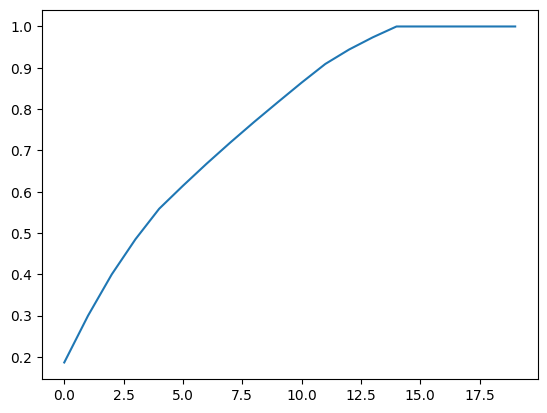

In [ ]:
import matplotlib.pyplot as plt
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.show()